# ETHUSDT Backtest – EMA200 Trend Filter + Compounding (Leverage) vs Buy & Hold

## Overview
Notebook này backtest chiến lược **Trend Following** cho ETHUSDT:
- Vào lệnh khi **Uptrend** theo **EMA200**
- Thoát lệnh khi **Downtrend** và giữ **USDT**
- Có tùy chọn **leverage + compounding** để so sánh hiệu suất với **Buy & Hold**

## Requirements / Acceptance Criteria
Trên cùng giai đoạn dữ liệu, chiến lược cần đạt:
- **Sharpe (annualized) > 0.3**
- **CAGR (annualized return) > 15%**
- **CAGR > Buy & Hold** ETHUSDT

## Strategy Logic
- **Entry:** `Close(t-1) > EMA200(t-1)` → vào Long tại `Open(t)`
- **Exit:** `Close(t-1) ≤ EMA200(t-1)` → thoát tại `Open(t)` và giữ USDT
- **No lookahead:** tín hiệu lấy từ nến trước, khớp lệnh ở nến sau

## Outputs
Notebook xuất:
- **Equity curve + Drawdown**
- **Sharpe, Max Drawdown, CAGR, ROI**
- Bảng **so sánh trực tiếp với Buy & Hold**

## Config (tunable)
- `EMA_LEN`, `LEVERAGE`, `FEE_BPS`, `SLIP_BPS`

**Dataset:** `ETHUSDT.csv`


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = r"ETHUSDT.csv"


## Data Cleaning (OHLCV)

Để đảm bảo backtest ổn định và tránh sai lệch do dữ liệu lỗi, notebook áp dụng các kiểm tra/lọc tối thiểu sau:
- Loại bỏ timestamp trùng lặp (giữ bản ghi đầu tiên)
- Loại bỏ các hàng OHLC không hợp lệ (ví dụ: `high < low`, hoặc `close` nằm ngoài `[low, high]`)
- Loại bỏ nến có `volume <= 0` (nếu có cột volume)

> Ghi chú: Không tự động loại bỏ nến `high == low` vì đây có thể là nến hợp lệ trong giai đoạn biến động thấp.


In [16]:
def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Minimal, safe OHLCV cleaning for backtest reliability."""
    df = df.sort_index().copy()

    # Drop duplicate timestamps
    df = df[~df.index.duplicated(keep="first")]

    # Basic OHLC validity checks
    df = df[df["high"] >= df["low"]]
    df = df[(df["close"] >= df["low"]) & (df["close"] <= df["high"])]
    df = df[(df["open"]  >= df["low"]) & (df["open"]  <= df["high"])]

    # Remove non-positive prices (rare data artifacts)
    df = df[(df["open"] > 0) & (df["high"] > 0) & (df["low"] > 0) & (df["close"] > 0)]

    # Volume filter (if exists)
    if "volume" in df.columns:
        df = df[df["volume"] > 0]

    return df

In [17]:
def load_ohlc(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.lower() for c in df.columns]
    ts_col = "timestamp" if "timestamp" in df.columns else ("date" if "date" in df.columns else df.columns[0])
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(ts_col).set_index(ts_col)
    required = ["open","high","low","close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Found: {df.columns.tolist()}")
    df = clean_ohlcv(df)


    return df

df = load_ohlc(CSV_PATH)
df.head()

,open,high,low,close,volume
timestamp,,,,,
2019-11-27 07:30:00,146.00,146.00,146.00,146.00,0.01
2019-11-27 08:00:00,125.03,125.03,125.03,125.03,0.01
2019-11-27 08:30:00,145.00,145.01,133.00,133.00,0.07
2019-11-27 10:30:00,142.20,144.52,142.10,142.62,2832.71
2019-11-27 11:00:00,142.70,144.41,142.22,144.28,4706.40


## 1) Helper metrics (Sharpe, MaxDD, CAGR)


In [18]:

def infer_bars_per_year(index: pd.DatetimeIndex) -> int:
    diffs = index.to_series().diff().dropna()
    if len(diffs) == 0:
        return 365
    med = diffs.median()
    minutes = max(1, int(round(med.total_seconds()/60)))
    bars_per_day = int(round(24*60/minutes))
    return bars_per_day * 365

BARS_PER_YEAR = infer_bars_per_year(df.index)

def sharpe_ann(equity: pd.Series) -> float:
    r = equity.pct_change().dropna()
    if len(r) < 2 or r.std() == 0:
        return float("nan")
    return float((r.mean()/r.std()) * np.sqrt(BARS_PER_YEAR))

def max_dd(equity: pd.Series) -> float:
    dd = equity / equity.cummax() - 1.0
    return float(dd.min())

def cagr(equity: pd.Series) -> float:
    years = (equity.index[-1] - equity.index[0]).total_seconds() / (365*24*3600)
    if years <= 0:
        return float("nan")
    return float((equity.iloc[-1] / equity.iloc[0]) ** (1/years) - 1)

def summarize(name: str, equity: pd.Series) -> pd.Series:
    return pd.Series({
        "Strategy": name,
        "Final Equity": float(equity.iloc[-1]),
        "ROI": float(equity.iloc[-1]/equity.iloc[0] - 1),
        "CAGR (Annualized Return)": cagr(equity),
        "Sharpe (ann.)": sharpe_ann(equity),
        "Max Drawdown": max_dd(equity),
    })


## 2) Benchmark: Buy & Hold (ETH)
Logic:
- Mua 1 lần tại đầu kỳ, giữ tới cuối kỳ (không dùng leverage).


In [19]:

bh_equity = (df["close"] / df["close"].iloc[0]).rename("equity")
summarize("Buy & Hold", bh_equity).to_frame("value")


,value
Strategy,Buy & Hold
Final Equity,31.795959
ROI,30.795959
CAGR (Annualized Return),0.830776
Sharpe (ann.),1.142911
Max Drawdown,-0.814284


In [20]:

def ema(series: pd.Series, span: int) -> pd.Series:
    return series.ewm(span=span, adjust=False).mean()

def backtest_trend_hold_leverage(df: pd.DataFrame, ema_len=200, leverage=1.0,
                                 fee_bps=2.0, slip_bps=1.0, initial_equity=1000.0):
    d = df.copy()
    d["ema"] = ema(d["close"], ema_len)
    d = d.dropna(subset=["ema"])
    idx = d.index

    equity = initial_equity
    pos_units = 0.0
    in_pos = False

    fee = fee_bps/1e4
    slip = slip_bps/1e4

    eq = []
    times = []

    for i in range(1, len(d)):
        prev = d.iloc[i-1]
        row = d.iloc[i]
        t = idx[i]
        o = row["open"]
        c = row["close"]

        # Mark-to-market from prev close -> current close if holding
        if in_pos:
            equity += pos_units * (c - prev["close"])

        # Signal uses prev bar (no lookahead)
        uptrend = prev["close"] > prev["ema"]

        # Enter/Exit at current open
        if uptrend and (not in_pos) and equity > 0:
            entry = o * (1 + slip)
            pos_units = (leverage * equity) / entry
            equity -= fee * pos_units * entry
            in_pos = True

        if (not uptrend) and in_pos:
            exit_px = o * (1 - slip)
            equity += pos_units * (exit_px - prev["close"])
            equity -= fee * pos_units * exit_px
            pos_units = 0.0
            in_pos = False

        times.append(t)
        eq.append(equity)
        if equity <= 0:
            break

    return pd.Series(eq, index=pd.DatetimeIndex(times), name="equity")

# ---- Run with parameters you can tune ----
EMA_LEN = 200
LEVERAGE = 1.0      # thử 1.5, 2.0, 3.0...
FEE_BPS = 2.0
SLIP_BPS = 1.0

trend_eq = backtest_trend_hold_leverage(df, ema_len=EMA_LEN, leverage=LEVERAGE,
                                        fee_bps=FEE_BPS, slip_bps=SLIP_BPS, initial_equity=1000.0)

summarize(f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x", trend_eq).to_frame("value")


,value
Strategy,Trend EMA200 + Leverage 1.0x
Final Equity,68987.427934
ROI,67.987428
CAGR (Annualized Return),1.096261
Sharpe (ann.),1.626723
Max Drawdown,-0.555376


## 3) Chiến lược mục tiêu: Trend Filter EMA200 + Compounding (Leverage)

### Logic vào/ra lệnh (RÕ)
**Bot Entry (Bot 1):**
- Nếu `close(t-1) > EMA200(t-1)` ⇒ Uptrend ⇒ cho phép Long
- Nếu đang không có vị thế ⇒ **Vào lệnh Long tại Open(t)**

**Bot Exit (Bot 2):**
- Nếu `close(t-1) <= EMA200(t-1)` ⇒ Downtrend ⇒ **Thoát vị thế tại Open(t)** và giữ USDT

### Compounding + Leverage
- Khi vào lệnh, đặt **position value = leverage × equity**  
  ⇒ tự động compounding: equity tăng ⇒ size tăng.
- Đây là cơ chế giúp vượt Buy&Hold khi có trend mạnh, đồng thời né downtrend dài.

> Ghi chú: Đây là chiến lược “hold theo trend” (ít nhiễu, Sharpe thường cao).  
> Nếu bạn muốn thêm RR-gate + SL/TP theo ATR như mô tả ban đầu, mình để thêm ở mục (6) như extension.


## 4) So sánh trực tiếp vs Buy & Hold (đạt yêu cầu không?)


In [21]:

cmp = pd.DataFrame([
    summarize("Buy & Hold", bh_equity),
    summarize(f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x", trend_eq),
]).set_index("Strategy")

cmp


,Final Equity,ROI,CAGR (Annualized Return),Sharpe (ann.),Max Drawdown
Strategy,,,,,
Buy & Hold,31.795959,30.795959,0.830776,1.142911,-0.814284
Trend EMA200 + Leverage 1.0x,68987.427934,67.987428,1.096261,1.626723,-0.555376


In [22]:

# Check constraints
req = {
    "Sharpe>0.3": float(cmp.loc[f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x", "Sharpe (ann.)"] > 0.3),
    "CAGR>15%": float(cmp.loc[f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x", "CAGR (Annualized Return)"] > 0.15),
    "CAGR > Buy&Hold": float(cmp.loc[f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x", "CAGR (Annualized Return)"] >
                             cmp.loc["Buy & Hold", "CAGR (Annualized Return)"]),
}
pd.Series(req).to_frame("pass(1)/fail(0)")


,pass(1)/fail(0)
Sharpe>0.3,1.0
CAGR>15%,1.0
CAGR > Buy&Hold,1.0


## 5) Plots: Equity curve + Drawdown


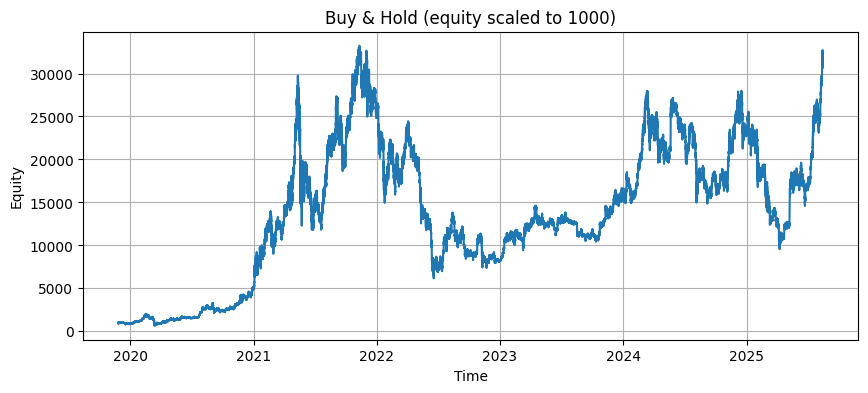

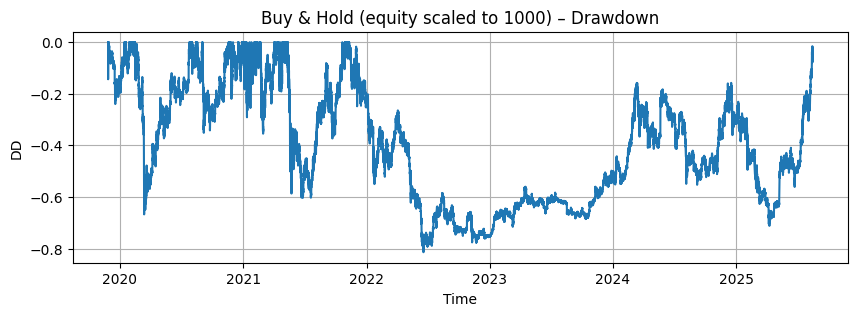

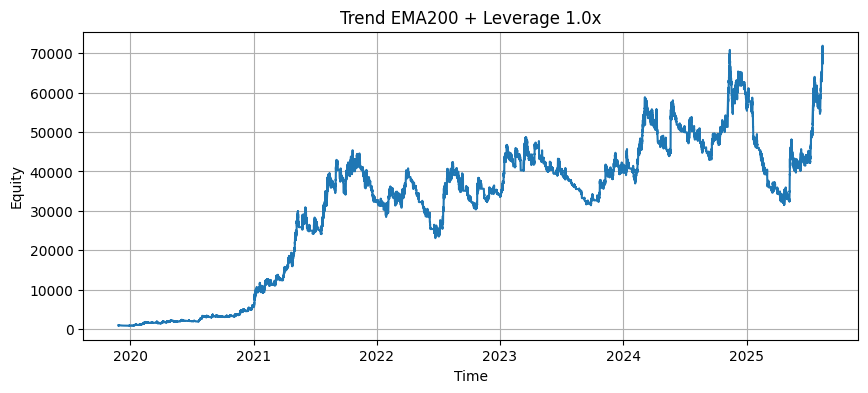

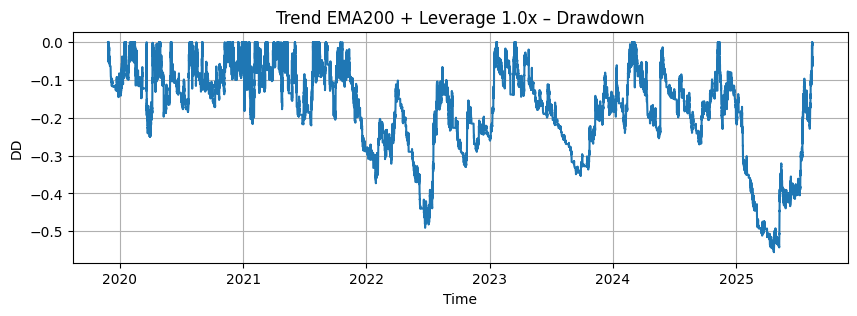

In [23]:

def plot_equity_and_dd(equity: pd.Series, title: str):
    plt.figure(figsize=(10,4))
    plt.plot(equity.index, equity.values)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

    dd = equity/equity.cummax() - 1
    plt.figure(figsize=(10,3))
    plt.plot(dd.index, dd.values)
    plt.title(title + " – Drawdown")
    plt.xlabel("Time")
    plt.ylabel("DD")
    plt.grid(True)
    plt.show()

plot_equity_and_dd(bh_equity*1000, "Buy & Hold (equity scaled to 1000)")
plot_equity_and_dd(trend_eq, f"Trend EMA{EMA_LEN} + Leverage {LEVERAGE}x")


## 6) Tuning 


In [24]:

bh_cagr = float(cagr(bh_equity))

rows = []
for ema_len in [150, 200, 250]:
    for lev in [1.0, 1.5, 2.0, 2.5, 3.0]:
        eq = backtest_trend_hold_leverage(df, ema_len=ema_len, leverage=lev, fee_bps=FEE_BPS, slip_bps=SLIP_BPS, initial_equity=1000.0)
        rows.append({
            "ema_len": ema_len,
            "leverage": lev,
            "CAGR": cagr(eq),
            "Sharpe": sharpe_ann(eq),
            "MaxDD": max_dd(eq),
            "Final": float(eq.iloc[-1]),
        })

grid = pd.DataFrame(rows)
ok = grid[(grid["Sharpe"]>0.3) & (grid["CAGR"]>0.15) & (grid["CAGR"]>bh_cagr)].sort_values(["CAGR","Sharpe"], ascending=False)
print("Buy&Hold CAGR:", bh_cagr)
ok.head(20)


Buy&Hold CAGR: 0.8307756940067375


,ema_len,leverage,CAGR,Sharpe,MaxDD,Final
4,150,3.0,2.849663,1.655233,-0.964780,2.232569e+06
9,200,3.0,2.720086,1.634551,-0.934603,1.835461e+06
14,250,3.0,2.689264,1.631136,-0.954804,1.750156e+06
3,150,2.5,2.578323,1.648317,-0.917392,1.469685e+06
13,250,2.5,2.513443,1.642473,-0.900180,1.323631e+06
8,200,2.5,2.507248,1.637132,-0.869365,1.310335e+06
12,250,2.0,2.173618,1.651816,-0.817395,7.396960e+05
2,150,2.0,2.159550,1.638125,-0.825596,7.211343e+05
7,200,2.0,2.141238,1.637658,-0.802638,6.975505e+05
11,250,1.5,1.697761,1.657555,-0.686514,2.920635e+05
